# Charging Station Scene Labeling via OSM POI

Use OpenStreetMap POI data to assign a scene label to each charging station, mapped to a simplified set of 9 NTS trip-purpose categories.

**Simplified label mapping (NTS -> 9 categories):**

| Label | Original NTS categories |
|---|---|
| `home` | Home, Escort home |
| `work` | Work, In course of work, Escort work, Escort in course of work |
| `education` | Education, Escort education |
| `shopping` | Food shopping, Non food shopping, Escort shopping/personal business |
| `personal_business` | Personal business medical/eat-drink/other |
| `social` | Eat/drink with friends, Visit friends, Other social |
| `leisure` | Entertain/public activity, Sport: participate, Day trip/just walk |
| `holiday` | Holiday: base |
| `other` | Other non-escort, Other escort |

**Method**: build a 500 m buffer around each charging-station coordinate, count nearby OSM POIs by category, and assign the label using weighted scores.

## 0. Install Dependencies

```bash
pip install osmnx geopandas shapely pandas tqdm pyarrow
```

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

ox.settings.log_console = False
ox.settings.use_cache = True   # Cache OSM queries to avoid repeated requests

## 1. Load Charging Station Data

In [2]:
df = pd.read_csv('../UK_OCM_stations.csv')
df = df.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)
print(f'Total charging stations: {len(df)}')
df.head()

Total charging stations: 26959


,StationID,Latitude,Longitude,Title,TotalCapacity_kW,StationType,Bands
0,194240,53.478011,-2.228680,NaN,2442.0,Fast site,Fast (8–49kW)
1,194241,55.952561,-3.183221,NaN,1848.0,Fast site,Fast (8–49kW)
2,155229,56.004720,-3.753830,NaN,1419.0,Fast site,Fast (8–49kW);Rapid (50–149kW)
3,256446,51.577544,-0.223825,NaN,1320.0,Fast site,Fast (8–49kW)
4,194034,51.459956,-0.970644,NaN,1106.0,Fast site,Slow (3–8kW)


## 2. Define POI Query Labels and Weights

Format: `{scene: [(osm_key, osm_value, weight), ...]}`  
A higher weight means the POI is more representative of that scene.

In [3]:
SCENE_TAGS = {
    # ── home ──────────────────────────────────────────────────────────────
    # NTS: Home, Escort home
    'home': [
        ('landuse',  'residential', 3),
        ('building', 'residential', 2),
        ('building', 'apartments',  2),
        ('building', 'house',       2),
        ('building', 'detached',    1),
        ('building', 'terrace',     1),
    ],

    # ── work ──────────────────────────────────────────────────────────────
    # NTS: Work, In course of work, Escort work, Escort in course of work
    'work': [
        ('landuse',  'commercial',  3),
        ('landuse',  'industrial',  2),
        ('building', 'office',      3),
        ('building', 'commercial',  2),
        ('building', 'industrial',  2),
        ('office',   True,          2),
        ('amenity',  'workplace',   2),
    ],

    # ── education ─────────────────────────────────────────────────────────
    # NTS: Education, Escort education
    'education': [
        ('amenity',  'school',       3),
        ('amenity',  'university',   3),
        ('amenity',  'college',      3),
        ('amenity',  'kindergarten', 2),
        ('landuse',  'education',    3),
        ('building', 'school',       2),
        ('building', 'university',   2),
    ],

    # ── shopping ──────────────────────────────────────────────────────────
    # NTS: Food shopping, Non food shopping, Escort shopping/personal business
    'shopping': [
        ('shop',     True,           3),
        ('landuse',  'retail',       3),
        ('building', 'retail',       2),
        ('building', 'supermarket',  2),
        ('amenity',  'marketplace',  2),
        ('amenity',  'food_court',   1),
    ],

    # ── personal_business ─────────────────────────────────────────────────
    # NTS: Personal business medical, Personal business eat/drink, Personal business other
    'personal_business': [
        ('amenity',  'hospital',      3),
        ('amenity',  'clinic',        3),
        ('amenity',  'doctors',       3),
        ('amenity',  'dentist',       2),
        ('amenity',  'pharmacy',      2),
        ('amenity',  'bank',          2),
        ('amenity',  'post_office',   1),
        ('amenity',  'restaurant',    1),
        ('amenity',  'cafe',          1),
        ('amenity',  'fast_food',     1),
        ('amenity',  'bar',           1),
    ],

    # ── social ────────────────────────────────────────────────────────────
    # NTS: Eat/drink with friends, Visit friends, Other social
    'social': [
        ('amenity',  'pub',           2),
        ('amenity',  'bar',           2),
        ('amenity',  'nightclub',     2),
        ('amenity',  'community_centre', 2),
        ('amenity',  'social_facility',  2),
        ('amenity',  'place_of_worship', 1),
        ('building', 'community_centre', 1),
    ],

    # ── leisure ───────────────────────────────────────────────────────────
    # NTS: Entertain/public activity, Sport: participate, Day trip/just walk
    'leisure': [
        ('leisure',  True,                 3),
        ('amenity',  'cinema',             2),
        ('amenity',  'theatre',            2),
        ('amenity',  'sports_centre',      2),
        ('amenity',  'swimming_pool',      2),
        ('sport',    True,                 2),
        ('landuse',  'recreation_ground',  2),
        ('landuse',  'grass',              1),
        ('natural',  'park',               1),
        ('tourism',  'attraction',         1),
    ],

    # ── holiday ───────────────────────────────────────────────────────────
    # NTS: Holiday: base
    'holiday': [
        ('tourism',  'hotel',         3),
        ('tourism',  'motel',         3),
        ('tourism',  'guest_house',   3),
        ('tourism',  'hostel',        2),
        ('tourism',  'camp_site',     2),
        ('tourism',  'caravan_site',  2),
        ('tourism',  'attraction',    1),
        ('tourism',  'museum',        1),
    ],

    # ── other ─────────────────────────────────────────────────────────────
    # NTS: Other non-escort, Other escort (fallback — no dominant POI signal)
    # (will only be assigned when all scores are tied at 0 → 'unknown' preferred)
}

RADIUS_M = 500  # Query radius in meters

## 3. Build Unified Query Tags

Merge OSM tags from all scenes into a single `QUERY_TAGS` dictionary so the later batch download only needs one request definition.

In [4]:
def _build_query_tags():
    """Merge OSM tags from all scenes into a one-shot query parameter set."""
    all_tags = {}
    for tag_list in SCENE_TAGS.values():
        for key, value, _ in tag_list:
            if key not in all_tags:
                all_tags[key] = set()
            if value is True:
                all_tags[key] = True
            elif all_tags[key] is not True:
                all_tags[key].add(value)
    for k in list(all_tags):
        if isinstance(all_tags[k], set):
            vals = list(all_tags[k])
            all_tags[k] = vals[0] if len(vals) == 1 else vals
    return all_tags

QUERY_TAGS = _build_query_tags()
print('OSM query keys:', list(QUERY_TAGS.keys()))

OSM query keys: ['landuse', 'building', 'office', 'amenity', 'shop', 'leisure', 'sport', 'natural', 'tourism']


## 4. Download Nearby OSM POIs in Tiles (Grid-Cached)

Send Overpass requests only for grid tiles intersecting the 500 m station neighborhoods, and cache each tile result as parquet.
This avoids one huge query over all of England; if the process is interrupted or fails, reruns only need to fill in missing tiles.

> The first download depends on the number of tiles and Overpass server load; later reruns usually read directly from cache.

In [5]:
from pathlib import Path

try:
    from osm_poi_cache import load_station_area_pois
except ImportError:
    from OSM_POI_Labeling.osm_poi_cache import load_station_area_pois

CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

pois = load_station_area_pois(
    df=df,
    query_tags=QUERY_TAGS,
    radius_m=RADIUS_M,
    cache_dir=CACHE_DIR,
    tile_size_m=25_000,
    overpass_timeout=180,
)

print(f'Total POIs: {len(pois):,}')
pois.head(3)

Loading cached station-area POIs...


Total POIs: 3,496,137


,osm_element,osm_id,landuse,building,office,amenity,shop,leisure,sport,natural,tourism,geometry
0,way,916921986,grass,None,None,None,None,None,None,None,None,"POLYGON ((-7.81318 54.25812, -7.81305 54.25812..."
1,node,9026374629,None,None,None,None,None,picnic_table,None,None,None,POINT (-7.813 54.25805)
2,way,375971097,None,yes,None,None,None,None,None,None,attraction,"POLYGON ((-7.8131 54.2584, -7.81309 54.25837, ..."


## 5. Projection and Spatial-Join Scoring

Create a 500 m buffer around each station, run a single `sjoin` against all POIs, and then aggregate scores in a vectorized way.  
This stage makes **0 network requests** and runs entirely locally.

In [6]:
# ── 1. Charging stations: points -> projected CRS -> 500 m buffers ───────
stations_gdf = gpd.GeoDataFrame(
    df[['StationID', 'Latitude', 'Longitude']],
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']),
    crs='EPSG:4326'
).to_crs('EPSG:27700')

stations_buf = stations_gdf.copy()
stations_buf['geometry'] = stations_buf.geometry.buffer(RADIUS_M)

# ── 2. POIs: project to the same CRS ──────────────────────────────────────
pois_proj = pois.to_crs('EPSG:27700')
poi_cols  = [c for c in QUERY_TAGS.keys() if c in pois_proj.columns] + ['geometry']

# ── 3. Spatial join: each POI -> intersecting station buffers ─────────────
print('Running spatial join...')
joined = gpd.sjoin(
    pois_proj[poi_cols],
    stations_buf[['StationID', 'geometry']],
    how='inner',
    predicate='intersects'
)
print(f'Join result: {len(joined):,} pairs (POI, charging station)')

# ── 4. Vectorized scoring ─────────────────────────────────────────────────
# For each (key, value, weight) rule, count matching POIs and accumulate
# weighted contributions into the corresponding scene.
records = []
for scene, tag_list in SCENE_TAGS.items():
    for key, value, weight in tag_list:
        if key not in joined.columns:
            continue
        mask = joined[key].notna() if value is True else (joined[key] == value)
        if not mask.any():
            continue
        contrib = (
            joined.loc[mask]
            .groupby('StationID')
            .size()
            .reset_index(name='count')
        )
        contrib['scene']        = scene
        contrib['contribution'] = contrib['count'] * weight
        records.append(contrib[['StationID', 'scene', 'contribution']])

score_df = (
    pd.concat(records, ignore_index=True)
    .groupby(['StationID', 'scene'])['contribution']
    .sum()
    .unstack(fill_value=0)
    .rename(columns=lambda c: f'score_{c}')
)

# Fill in any missing scene-score columns.
for scene in SCENE_TAGS:
    col = f'score_{scene}'
    if col not in score_df.columns:
        score_df[col] = 0

# ── 5. Determine the final label (highest-scoring scene; all-zero -> unknown)
score_cols = [f'score_{s}' for s in SCENE_TAGS]
score_df['label'] = score_df[score_cols].apply(
    lambda row: row.idxmax().replace('score_', '') if row.max() > 0 else 'unknown',
    axis=1
)

# Merge back into the original station table (stations with no matched POIs
# are labeled as unknown).
df_labeled = df[['StationID']].merge(score_df.reset_index(), on='StationID', how='left')
df_labeled['label'] = df_labeled['label'].fillna('unknown')
for col in score_cols:
    df_labeled[col] = df_labeled[col].fillna(0).astype(int)

print(df_labeled['label'].value_counts())

Running spatial join...
Join result: 17,934,496 pairs (POI, charging station)
label
home                 20419
shopping              3173
leisure               2435
work                   754
holiday                 68
unknown                 49
education               46
social                   9
personal_business        6
Name: count, dtype: int64


## 6. Merge and Save Results

In [8]:
output_path = '../UK_OCM_stations_labeled.csv'
merge_cols = ['StationID', 'label'] + [f'score_{s}' for s in SCENE_TAGS]
df_out = df.merge(df_labeled[merge_cols], on='StationID', how='left')
df_out.to_csv(output_path, index=False)
print(f'Saved to {output_path}')
df_out['label'].value_counts()

Saved to ../UK_OCM_stations_labeled.csv


label
home                 20419
shopping              3173
leisure               2435
work                   754
holiday                 68
unknown                 49
education               46
social                   9
personal_business        6
Name: count, dtype: int64

## 7. Visualization

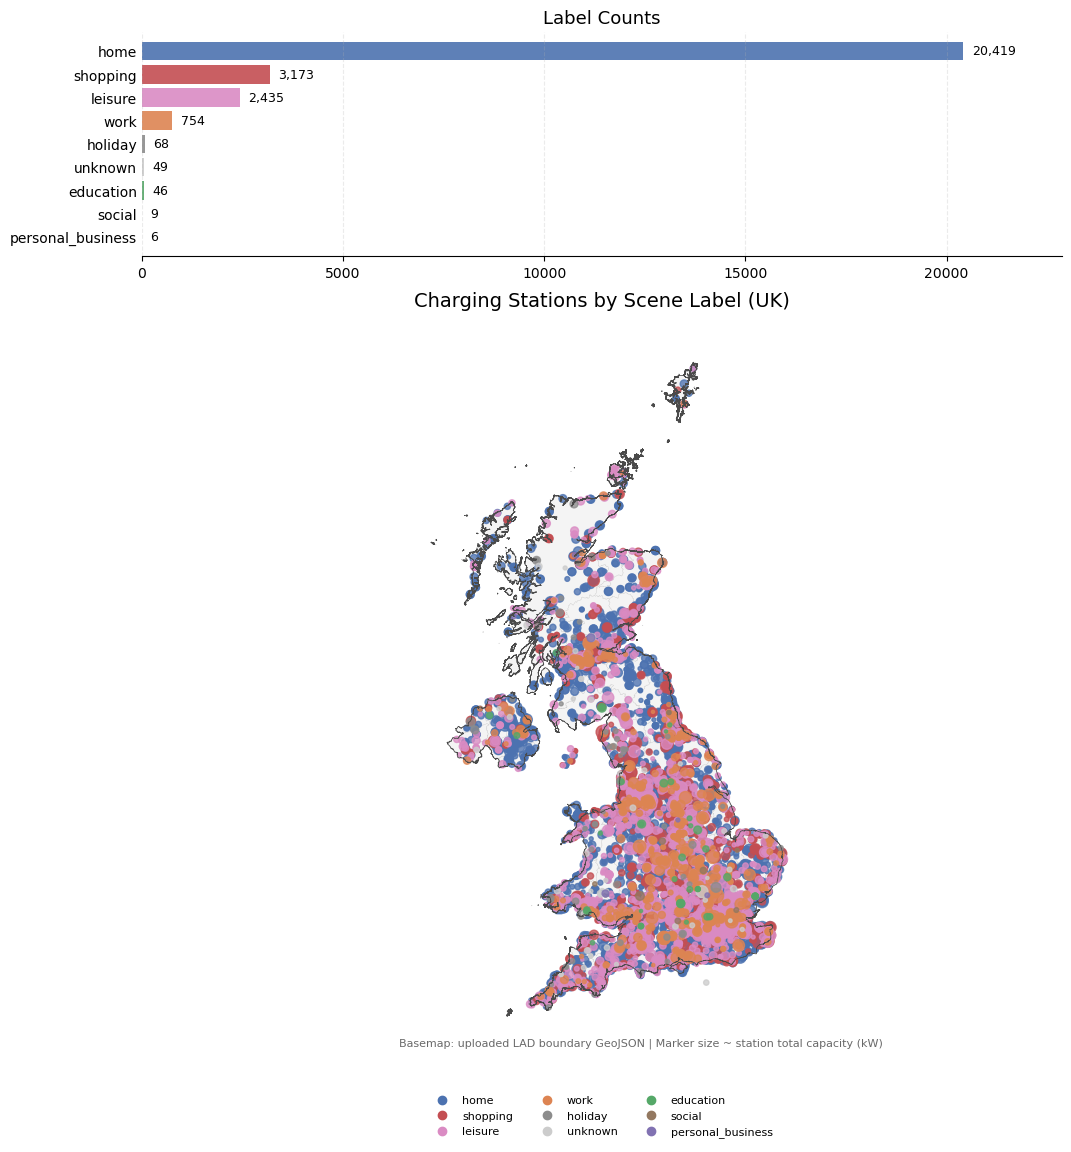

In [10]:
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

LABEL_COLORS = {
    'home':              '#4C72B0',
    'work':              '#DD8452',
    'education':         '#55A868',
    'shopping':          '#C44E52',
    'personal_business': '#8172B2',
    'social':            '#937860',
    'leisure':           '#DA8BC3',
    'holiday':           '#8C8C8C',
    'other':             '#64B5CD',
    'unknown':           '#CCCCCC',
}


BOUNDARY_FILENAME = 'Local_Authority_Districts_May_2024_Boundaries_UK_BFE_15392903039356303.geojson'


def load_uk_regions():
    candidates = [
        Path(BOUNDARY_FILENAME),
        Path('OSM_POI_Labeling') / BOUNDARY_FILENAME,
    ]

    for boundary_path in candidates:
        if boundary_path.exists():
            uk = gpd.read_file(boundary_path)
            if uk.empty:
                raise ValueError(f'Boundary file is empty: {boundary_path}')
            if uk.crs is None:
                raise ValueError(f'Boundary file is missing CRS information: {boundary_path}')
            return uk.to_crs('EPSG:4326')

    raise FileNotFoundError(f'Uploaded boundary file not found: {BOUNDARY_FILENAME}')


uk_regions = load_uk_regions()
uk_outline = gpd.GeoDataFrame(geometry=[uk_regions.geometry.union_all()], crs=uk_regions.crs)

df_plot = df_out.dropna(subset=['Latitude', 'Longitude']).copy()
df_plot['label_clean'] = (
    df_plot['label']
    .fillna('unknown')
    .astype(str)
    .str.strip()
    .replace({'': 'unknown'})
)

cap_series = pd.to_numeric(df_plot['TotalCapacity_kW'], errors='coerce').fillna(1).clip(lower=1)
cap_max = max(float(cap_series.max()), 1.0)


def radius_from_capacity(cap):
    cap = max(float(cap) if pd.notna(cap) else 1.0, 1.0)
    if cap_max <= 1.0:
        return 3.0

    norm = np.log10(cap) / np.log10(cap_max)
    norm = np.clip(norm, 0, 1) ** 1.35
    min_r = 2.0
    max_r = 12.0
    return min_r + norm * (max_r - min_r)


df_plot['radius'] = cap_series.apply(radius_from_capacity)
df_plot['marker_size'] = (df_plot['radius'] ** 2) * 0.8

counts = df_plot['label_clean'].value_counts()
legend_labels = counts.index.tolist()

fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 4.0], hspace=0.12)
ax_summary = fig.add_subplot(gs[0])
ax_map = fig.add_subplot(gs[1])

count_values = counts.sort_values(ascending=True)
ax_summary.barh(
    count_values.index,
    count_values.values,
    color=[LABEL_COLORS.get(label, '#CCCCCC') for label in count_values.index],
    alpha=0.9
)
for y, value in enumerate(count_values.values):
    ax_summary.text(
        value + max(count_values.max() * 0.01, 5),
        y,
        f'{value:,}',
        va='center',
        fontsize=9
    )
ax_summary.set_title('Label Counts', fontsize=13)
ax_summary.grid(axis='x', linestyle='--', alpha=0.25)
for spine in ['top', 'right', 'left']:
    ax_summary.spines[spine].set_visible(False)
ax_summary.tick_params(axis='y', length=0)
ax_summary.set_xlim(0, count_values.max() * 1.12)

ax_map.set_facecolor('#FCFCFC')
uk_regions.plot(
    ax=ax_map,
    legend=False,
    edgecolor='#C6C6C6',
    linewidth=0.18,
    facecolor='#F4F4F4'
)
uk_outline.boundary.plot(
    ax=ax_map,
    color='#4A4A4A',
    linewidth=0.55
)

for label in legend_labels:
    sub = df_plot[df_plot['label_clean'] == label]
    if sub.empty:
        continue
    ax_map.scatter(
        sub['Longitude'],
        sub['Latitude'],
        s=sub['marker_size'],
        color=LABEL_COLORS.get(label, '#CCCCCC'),
        alpha=0.78
    )

minx, miny, maxx, maxy = uk_outline.total_bounds
ax_map.set_xlim(minx - 1.2, maxx + 0.9)
ax_map.set_ylim(miny - 0.8, maxy + 0.8)
ax_map.set_title('Charging Stations by Scene Label (UK)', fontsize=14)
ax_map.text(
    0.02, 0.02,
    'Basemap: uploaded LAD boundary GeoJSON | Marker size ~ station total capacity (kW)',
    transform=ax_map.transAxes,
    fontsize=8,
    color='dimgray',
    verticalalignment='bottom'
)
ax_map.set_axis_off()

legend_handles = [
    Line2D(
        [0], [0], marker='o', linestyle='',
        markerfacecolor=LABEL_COLORS.get(label, '#CCCCCC'),
        markeredgecolor=LABEL_COLORS.get(label, '#CCCCCC'),
        markersize=6
    )
    for label in legend_labels
]

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center',
    ncol=3,
    fontsize=8,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02)
)

fig.subplots_adjust(top=0.95, bottom=0.09, left=0.04, right=0.96, hspace=0.12)
plt.savefig('label_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
